## 网格搜索交叉验证 (Grid Search Cross-Validation)

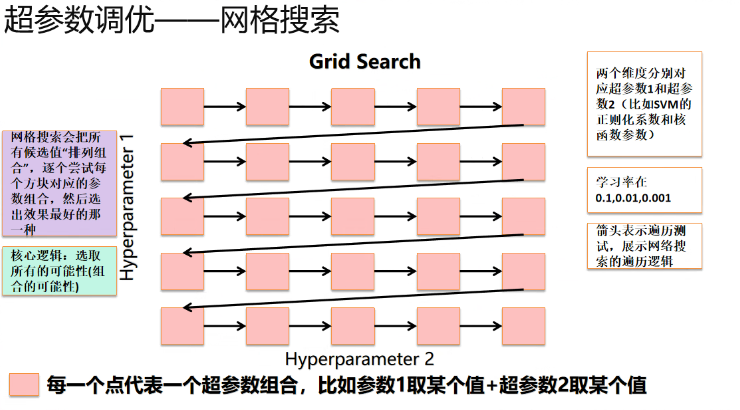

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris #导入鸢尾花数据集
#加载数据集
iris = load_iris()
X, y = iris.data, iris.target #特征矩阵和目标向量
#定义模型
svm = SVC(kernel='linear', C=100, gamma='auto') #Kernel:线性核函数，C:正则化参数，gamma:核函数系数
#定义参数网格
param_grid = {
    "C": [0.1, 1, 10, 100], #不同的C值
    "gamma": [1e-3, 1e-2, 1e-1, 1] #不同的gamma值
}

#创建网格搜索对象，同时设置好交叉验证
grid_search = GridSearchCV(svm, param_grid, cv=5) #5折交叉验证

#对数据进行网格搜索
grid_search.fit(X, y) #训练模型
#输出最佳参数组合和对应的得分
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Score:', grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.001}
Best Cross-Validation Score: 0.9800000000000001


In [22]:
#定义搜索参数
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

param_gird = [
    { #第一种参数组合：权重为‘uniform’（均匀权重），邻居数从1到10
        'weights': ['uniform'],
        'n_neighbors': [i for i in range(1, 11)],
    },
    {
        'weights': ['distance'],
        'n_neighbors': [i for i in range(1, 11)],
        'p': [i for i in range(1, 6)],
    }
]
knn_clf = KNeighborsClassifier(n_jobs=-1) #使用所有CPU核心
grid_search = GridSearchCV(knn_clf, param_gird, cv=5, n_jobs=-1) #使用所有CPU核心进行网格搜索
grid_search.fit(X_train, y_train) #训练模型


,estimator,KNeighborsCla...ier(n_jobs=-1)
,param_grid,"[{'n_neighbors': [1, 2, ...], 'weights': ['uniform']}, {'n_neighbors': [1, 2, ...], 'p': [1, 2, ...], 'weights': ['distance']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [23]:
grid_search.best_params_ #输出最佳参数组合

{'n_neighbors': 7, 'p': 3, 'weights': 'distance'}

In [24]:
grid_search.best_score_ #输出最佳交叉验证得分

np.float64(0.975)

In [25]:
grid_search.best_params_ #输出最佳参数组合

{'n_neighbors': 7, 'p': 3, 'weights': 'distance'}

In [26]:
knn_clf = grid_search.best_estimator_ #获取最佳模型
knn_clf.score(X_test, y_test) #在测试集上评估模型

1.0

In [29]:
#调参

grid_search = GridSearchCV(knn_clf, param_gird, n_jobs=-1, verbose=2) #使用所有CPU核心进行网格搜索
grid_search.fit(X_train, y_train) #训练模型

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,KNeighborsCla...ts='distance')
,param_grid,"[{'n_neighbors': [1, 2, ...], 'weights': ['uniform']}, {'n_neighbors': [1, 2, ...], 'p': [1, 2, ...], 'weights': ['distance']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [ ]:
grid_search.best_score_  #输出最佳得分

np.float64(0.975)

In [31]:
grid_search.best_params_ #输出最佳参数组合


{'n_neighbors': 7, 'weights': 'uniform'}

In [32]:
#数据归一化Feature Scaling
#解决方法：将所有数据映射到同一尺度
import numpy as np
x = np.random.randint(0, 100, size=100)
x

array([48, 99, 23, 70, 25, 49, 37, 15, 12,  5, 39, 61, 63, 33, 35, 50, 64,
       38, 90, 50, 25, 79, 67, 16, 63, 51, 46, 32, 42, 38, 13, 81, 72, 19,
       26, 29, 44, 41, 90, 95, 44,  9, 40, 34, 47, 62, 96, 19, 27,  5, 50,
       59, 52, 36, 53, 93, 62, 57, 76, 13, 65, 65, 66, 19, 58, 70, 49, 70,
       59, 24, 73, 43,  3, 90, 52, 70, 37, 39, 64, 44, 46, 70, 68, 12, 85,
       17, 92, 83, 46, 18, 61, 33, 48,  1, 13,  0, 22, 25, 98, 54],
      dtype=int32)

In [33]:
#归一化
(x-np.min(x))/(np.max(x)-np.min(x))

array([0.48484848, 1.        , 0.23232323, 0.70707071, 0.25252525,
       0.49494949, 0.37373737, 0.15151515, 0.12121212, 0.05050505,
       0.39393939, 0.61616162, 0.63636364, 0.33333333, 0.35353535,
       0.50505051, 0.64646465, 0.38383838, 0.90909091, 0.50505051,
       0.25252525, 0.7979798 , 0.67676768, 0.16161616, 0.63636364,
       0.51515152, 0.46464646, 0.32323232, 0.42424242, 0.38383838,
       0.13131313, 0.81818182, 0.72727273, 0.19191919, 0.26262626,
       0.29292929, 0.44444444, 0.41414141, 0.90909091, 0.95959596,
       0.44444444, 0.09090909, 0.4040404 , 0.34343434, 0.47474747,
       0.62626263, 0.96969697, 0.19191919, 0.27272727, 0.05050505,
       0.50505051, 0.5959596 , 0.52525253, 0.36363636, 0.53535354,
       0.93939394, 0.62626263, 0.57575758, 0.76767677, 0.13131313,
       0.65656566, 0.65656566, 0.66666667, 0.19191919, 0.58585859,
       0.70707071, 0.49494949, 0.70707071, 0.5959596 , 0.24242424,
       0.73737374, 0.43434343, 0.03030303, 0.90909091, 0.52525

In [34]:
#二维or多维数据均可归一化
X = np.random.randint(0, 100, size=(50, 2))
X = np.array(X, dtype=np.float32)
X[:, 0] = (X[:, 0]-np.min(X[:, 0]))/(np.max(X[:, 0])-np.min(X[:, 0]))
X[:, 1] = (X[:, 1]-np.min(X[:, 1]))/(np.max(X[:, 1])-np.min(X[:, 1]))
X[:10, :]

array([[0.35051546, 0.82978725],
       [0.97938144, 0.35106382],
       [0.05154639, 0.5851064 ],
       [0.16494845, 0.11702128],
       [0.92783505, 0.64893615],
       [0.31958762, 0.9468085 ],
       [0.31958762, 0.5851064 ],
       [0.        , 0.79787236],
       [0.03092784, 0.31914893],
       [0.742268  , 1.        ]], dtype=float32)

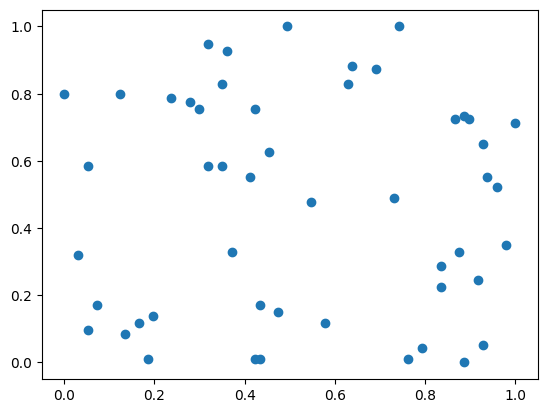

In [35]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [36]:
print(np.mean(X), np.std(X))

0.5003334 0.31356192


In [38]:
#均值方差归一化standardization
#数据分布没有明显的边界，可能存在极端的数据值
x2 = np.random.randint(0, 100, (50, 2))
x2 = np.array(X, dtype=float)
#对x2的第一列数据进行标准化
x2[:, 0] = (x2[:, 0]-np.mean(x2[:, 0]))/np.std(x2[:, 0])
x2[:, 1] = (x2[:, 1]-np.mean(x2[:, 1]))/np.std(x2[:, 1])


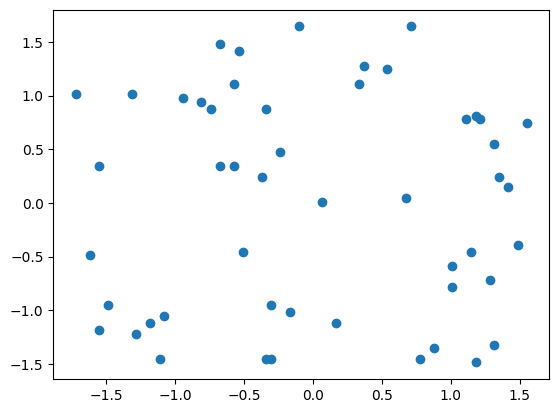

-1.0547118733938987e-16 0.9999999999999999


In [40]:
import matplotlib.pyplot as plt
plt.scatter(x2[:, 0], x2[:, 1])
plt.show()
print(np.mean(x2), np.std(x2))

In [41]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# 加载数据
iris = datasets.load_iris()
X, y = iris.data, iris.target

# 划分数据集 (增加分层抽样)
# 注意：原图中写的是 X_tost，这里已修正为 X_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# 1. 比较不同的归一化方法
scalers = { # 定义字典存储不同的数据预处理 (归一化/标准化) 方法
    # 注意：原图中拼写为 StancardScaler，这里已修正
    'StandardScaler': StandardScaler(), # 标准化 (Z-Score)：均值0, 方差1
    'MinMaxScaler': MinMaxScaler(),     # 最小最大值归一化：映射到[0,1]区间
    'RobustScaler': RobustScaler(),     # 鲁棒归一化：基于分位数，抗异常值
    'None': None                        # 无需处理，直接使用原始数据
}

# 存储不同归一化方法的交叉验证结果
cv_results = []

# 2. 创建包含预处理和模型的 Pipeline
for name, scaler in scalers.items(): # 遍历所有的处理化方法 创建“预处理+模型”的流水线(Pipeline)
    if scaler: # 判断当前是否需要预处理，(scaler不为None)
        # 创建流水线：第一步用指定的scaler预处理数据，第二步用KNN分类器 (k=3)
        pipeline = Pipeline([
            ('Scaler', scaler), # 预处理步骤，使用当前遍历的归一化方法
            ('classifier', KNeighborsClassifier(n_neighbors=3)) # 分类模型：KNN (k=3)
        ])
    else:
        # 无需处理时，流水线仅包含KNN分类器 (直接用原始数据训练)
        pipeline = Pipeline([
            ('classifier', KNeighborsClassifier(n_neighbors=3)) # 仅分类模型，无需处理
        ])
    
    # 进行5折交叉验证
    # 对当前流水线进行5折交叉验证，评估指标为准确率 (accuracy)
    # cross_val_score 还会自动分割数据、训练模型并返回每次折的准确率
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # 以字典列表形式存储结果，便于后续可视化
    for score in scores:
        cv_results.append({
            'scaler': name,   # 记录当前使用的预处理方法名称
            # 注意：原图中写的是 sccre，这里已修正为 score
            'accuracy': score # 记录当前折的交叉验证准确率
        })
    
    # 打印当前预处理方法的交叉验证结果：均值 (±标准差)，保留4位小数
    print(f"{name} 交叉验证准确率: {scores.mean():.4f} ± {scores.std():.4f}")

StandardScaler 交叉验证准确率: 0.9583 ± 0.0373
MinMaxScaler 交叉验证准确率: 0.9750 ± 0.0204
RobustScaler 交叉验证准确率: 0.9167 ± 0.0264
None 交叉验证准确率: 0.9750 ± 0.0204


开始交叉验证计算特征重要性...


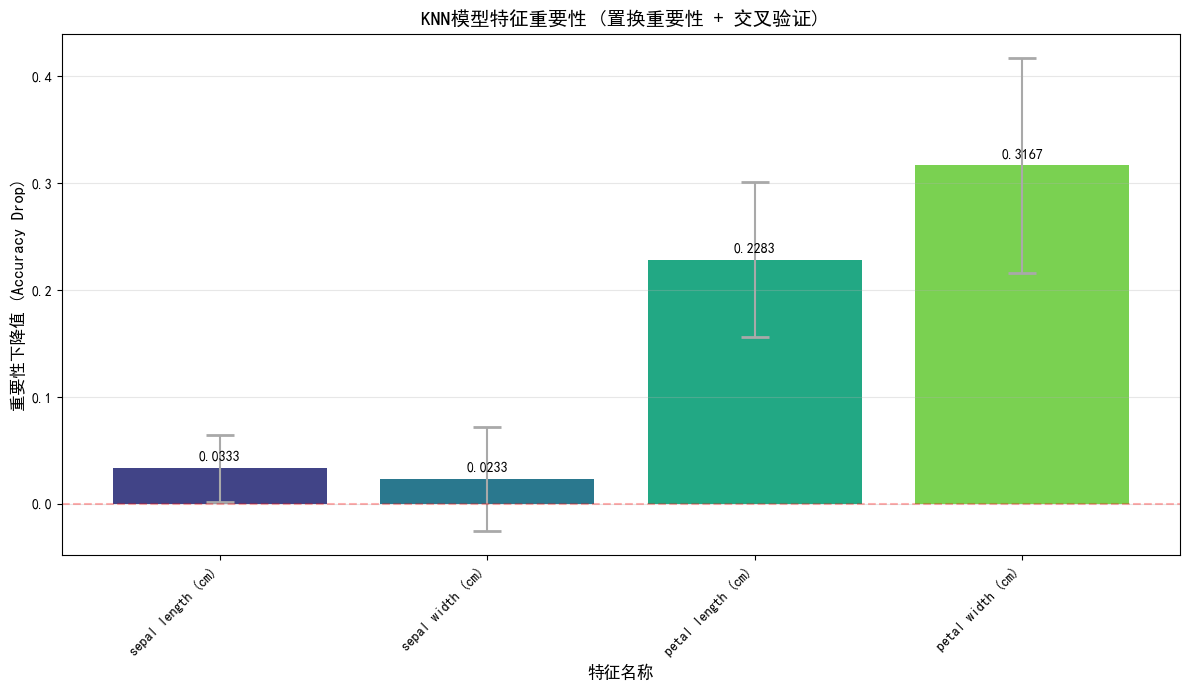


特征重要性排序：
                特征名称   平均重要性  重要性标准差  测试集重要性   综合重要性
3   petal width (cm)  0.2667  0.1007  0.4333  0.3167
2  petal length (cm)  0.1833  0.0726  0.3333  0.2283
0  sepal length (cm)  0.0333  0.0312  0.0333  0.0333
1   sepal width (cm)  0.0333  0.0486  0.0000  0.0233


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

# --- 1. 数据准备 (模拟上下文) ---
# 加载示例数据
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 模拟之前的 GridSearch 过程，获取最佳参数
# 这里直接手动指定一个参数作为示例
best_params = {'n_neighbors': 5, 'weights': 'uniform'} 
# 如果你实际有 grid_search 对象，请保留你的代码：
# best_params = {k.replace('classifier__', ''): v for k, v in grid_search.best_params_.items()}

# --- 2. 代码修正与优化 ---

# 设置随机种子
np.random.seed(42)

# 修正：虽然在这里标准化对于演示是可以的，但在严格的CV中应放入循环内。
# 为了保持你代码的原意，这里先保留，但在CV内部再次处理会更严谨。
# 这里采用你的逻辑：先处理整个训练集
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# 初始化存储特征的重要性数据
n_features = X_train.shape[1]
n_splits = 5
perm_importances = np.zeros((n_splits, n_features))

# 创建K折交叉验证
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

print("开始交叉验证计算特征重要性...")

for split_idx, (train_index, val_index) in enumerate(kf.split(X_train_scaled)):
    # 分割当前折
    X_tr, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    # 训练模型
    model = KNeighborsClassifier(**best_params)
    model.fit(X_tr, y_tr)
    
    # 计算基准准确率
    baseline_score = model.score(X_val, y_val)
    
    # 计算每个特征的重要性
    for feature_idx in range(n_features):
        # 修正：对于numpy数组，.copy() 比 deepcopy 快
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, feature_idx])  # 打乱当前特征列
        
        permuted_score = model.score(X_val_permuted, y_val)
        
        # 重要性 = 基准 - 打乱后 (若数值下降多，说明特征重要)
        perm_importances[split_idx, feature_idx] = baseline_score - permuted_score

# 计算统计量
mean_importance = np.mean(perm_importances, axis=0)
# 修正：变量名错误，应为 perm_importances
std_importance = np.std(perm_importances, axis=0)

# --- 结合测试集的置换重要性分析 ---
test_importance = []
test_model = KNeighborsClassifier(**best_params)
test_model.fit(X_train_scaled, y_train)
base_test_score = test_model.score(X_test_scaled, y_test)

for feature_idx in range(n_features):
    X_test_permuted = X_test_scaled.copy()
    # 修正：去掉了多余的空格
    np.random.shuffle(X_test_permuted[:, feature_idx])
    # 修正：去掉了多余的空格
    permuted_test_score = test_model.score(X_test_permuted, y_test)
    # 修正：去掉了多余的空格
    test_importance.append(base_test_score - permuted_test_score)

# 结合交叉验证和测试集的分数
combined_importance = 0.7 * mean_importance + 0.3 * np.array(test_importance)

# 修正：去掉了多余的空格
importance_data = pd.DataFrame({
    '特征名称': iris.feature_names,
    '综合重要性': combined_importance,
    '重要性标准差': std_importance
})

# --- 可视化 ---
# 设置中文字体 (视你的环境而定，如果是Windows通常不需要额外设置，Linux/Mac可能需要)
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

plt.figure(figsize=(12, 7))

bars = plt.bar(
    x=importance_data['特征名称'],
    height=importance_data['综合重要性'],
    yerr=importance_data['重要性标准差'],
    capsize=10,
    error_kw={'ecolor': 'darkgray', 'capthick': 2},
    color=sns.color_palette('viridis', n_colors=n_features)
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.005 if height > 0 else height - 0.01, # 稍微调整位置逻辑防止重叠
        f'{height:.4f}',
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontweight='bold'
    )

plt.title('KNN模型特征重要性 (置换重要性 + 交叉验证)', fontsize=14)
plt.ylabel('重要性下降值 (Accuracy Drop)', fontsize=12)
plt.xlabel('特征名称', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 排序和统计 ---
importance_df = pd.DataFrame({
    '特征名称': iris.feature_names,
    '平均重要性': mean_importance,
    '重要性标准差': std_importance,
    '测试集重要性': test_importance,
    '综合重要性': combined_importance
})

# 修正：sort_values 拼写错误，以及列名错误 '综合重要行' -> '综合重要性'
importance_df = importance_df.sort_values('综合重要性', ascending=False)

print('\n特征重要性排序：')
print(importance_df.round(4))

## 进阶版：随机搜索（Randomized Search）
- 工具：sklearn.model_selection.RandomizedSearchCV
- 逻辑：抽样。它不像网格那样把每个点都跑一遍，而是在你给定的范围内随机抽取固定的次数（比如只试 100 次）。
- 优点：速度快，而且效果往往出奇的好。研究表明，随机搜索通常能以远少于网格搜索的时间找到非常接近最优解的参数。
- 适用场景：参数空间很大，或者不知道哪个参数更重要时。

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # 引入切分工具

# 1. 准备数据
iris = load_iris()
X, y = iris.data, iris.target

# 必须切分数据：80%用于训练，20%用于验证（并未参与训练，这样评分才客观）
# shuffle=True 会自动打乱数据，解决Iris数据有序的问题
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 定义随机搜索函数
def random_search(X_train, y_train, X_val, y_val, model, param_space, iteration_num):
    best_score = -1
    best_params = None
    
    for i in range(iteration_num):
        # 随机采样参数
        paras = {k: v[np.random.randint(0, len(v))] for k, v in param_space.items()}
        
        # 设置参数
        model.set_params(**paras)
        
        # --- 核心修改 ---
        # 1. 只在训练集上 fit
        model.fit(X_train, y_train)
        # 2. 在验证集上 score (考卷必须是没见过的题)
        score = model.score(X_val, y_val)
        
        # 打印一下过程（可选，方便观察）
        # print(f"Iter {i}: score={score:.4f}, params={paras}")

        # 更新最佳参数
        if score > best_score:
            best_score = score
            best_params = paras
            
    return best_params, best_score

# 定义参数空间
model = RandomForestClassifier()
param_space = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    'max_features': ['sqrt', 'log2'], # 去掉了过时的 'auto'
    'bootstrap': [True, False]
}

# 执行随机搜索
# 注意：这里接收返回值的顺序修正了，或者让函数返回顺序匹配
best_params, best_score = random_search(X_train, y_train, X_val, y_val, model, param_space, iteration_num=20)

print('-' * 30)
print('Best Score (Validation):', best_score)
print('Best Parameters:', best_params)

------------------------------
Best Score (Validation): 1.0
Best Parameters: {'n_estimators': 50, 'max_depth': 20, 'max_features': 'sqrt', 'bootstrap': False}


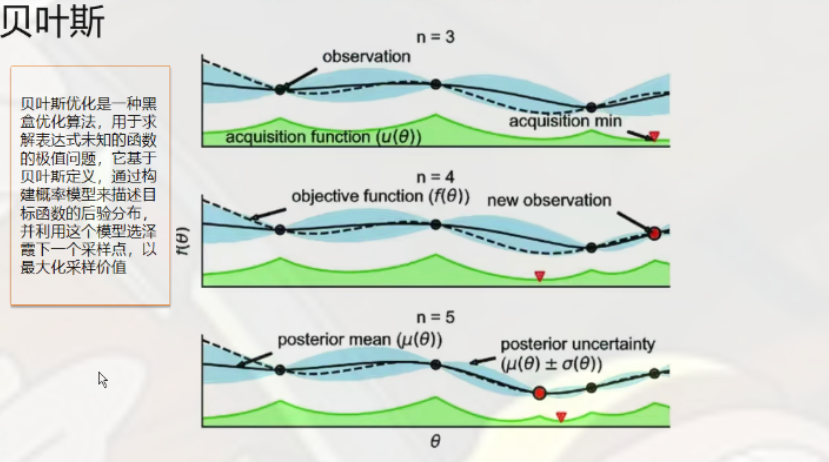
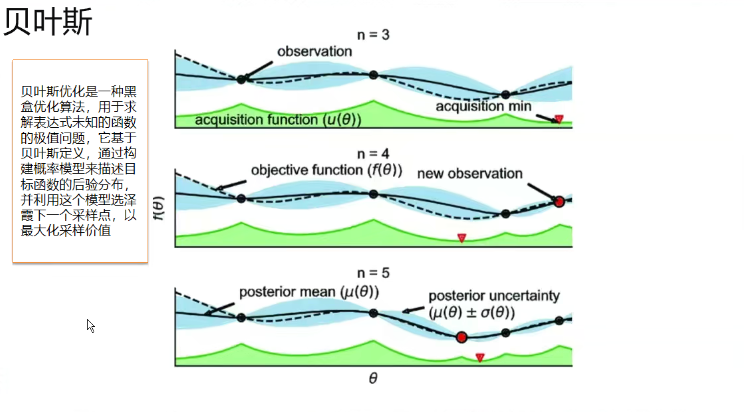

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
digits = datasets.load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn_clf = KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train, y_train)
knn_clf.score(X_test, y_test)

0.9833333333333333

In [ ]:
#寻找最好的 k 值
best_score = 0.0
best_k = -1
for k in range(1, 11):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train, y_train)
    score = knn_clf.score(X_test, y_test)
    if score > best_score:
        best_score = score
        best_k = k
print(f"Best k: {best_k}, Best Score: {best_score}")

Best k: 6, Best Score: 0.9888888888888889


In [ ]:
#是否考虑距离
best_score = 0.0
best_method = ""
best_k = -1
for method in {"uniform", "distance"}: #两种权重方法
    for k in range(1, 11):
        knn_clf = KNeighborsClassifier(n_neighbors=k, weights=method)
        knn_clf.fit(X_train, y_train)
        score = knn_clf.score(X_test, y_test)
        if score > best_score:
            best_k = k
            best_score = score
            best_method = method
print("best_method=",best_method)
print("best_k=", best_k)
print("best_score=", best_score)

best_method= distance
best_k= 6
best_score= 0.9888888888888889


In [ ]:
#搜索闵可夫斯基距离的最佳 p 值
#初始最优p值
best_p = -1
#初始最优分数
best_score = 0.0
#初始化最优k值，初始值设为-1
best_k = -1
#遍历k范围：1-10
for k in range(1, 11):
    for p in range(1, 6):
        #初始化j近邻分类器
        knn_clf = KNeighborsClassifier(n_neighbors=k,weights='distance', n_jobs=-1, p=p)
        knn_clf.fit(X_train, y_train)
        score = knn_clf.score(X_test, y_test)
        if score > best_score:
            best_k = k
            best_score = score
            best_p = p
print("best_p=", best_p)
print("best_k=", best_k)
print("best_score=", best_score)